# Zhangs Camera Calibration
### Read all images and select 3 randomly

In [86]:
import cv2
import numpy as np
from scipy.optimize import minimize
import os
import random
import matplotlib.pyplot as plt

In [119]:
# Visualisation functions
def show_image(img, title="Image"):
    """
    Displays an image using matplotlib.
    
    Parameters:
    -----------
    img : np.ndarray
        The image array (grayscale or color).
    title : str, optional
        Title for the plot.
    """

    # Convert image to numpy array (in case it's not)
    img = np.array(img)

    plt.figure(figsize=(12, 12))
    plt.title(title)
    plt.axis('off')

    # If the image has 3 channels, assume it's color (RGB or BGR)
    if len(img.shape) == 3:
        # If it's BGR (as from OpenCV), convert to RGB
        if img.shape[2] == 3:
            img = img[..., ::-1]  # flip color channels
        plt.imshow(img)
    else:
        # Grayscale image
        plt.imshow(img, cmap='gray')

    plt.show()

def show_filter_bank(filters, r, c, figsize=(12, 8), cmap='gray', titles=None):
    """
    Display a list of filters in a grid of r rows and c columns.
    Supports both grayscale and color filters.

    Parameters:
        filters (list of arrays): Filters to display (2D or 3D arrays)
        r (int): Number of rows
        c (int): Number of columns
        figsize (tuple): Figure size
        cmap (str): Colormap for grayscale images
        titles (list of str): Optional titles for each filter
    """
    n = len(filters)
    plt.figure(figsize=figsize)
    
    for i in range(r*c):
        plt.subplot(r, c, i+1)
        if i < n:
            f = filters[i]
            # If grayscale, use cmap; if color, no cmap
            if f.ndim == 2:
                plt.imshow(f, cmap=cmap)
            elif f.ndim == 3 and f.shape[2] in [3, 4]:  # RGB or RGBA
                # Convert BGR to RGB for proper display
                f_rgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB) if f.shape[2] == 3 else f
                plt.imshow(f_rgb)
            else:
                # fallback for unexpected shapes
                plt.imshow(f, cmap=cmap)
            plt.axis('off')
            if titles:
                plt.title(titles[i], fontsize=00)
        else:
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def show_side_by_side(image0,  image2, title= "", figsize=(10, 6)):
    titles = ["Before "+ title, "After " + title]
    bank = [image0, image2]
    show_filter_bank(bank, 1, 2, figsize, None ,titles)

def draw_corners(img,  corners, color = (0, 0, 255)):
    c_img = img.copy()
    if corners is not None:
        for corner in corners:
            x, y = corner.ravel()  # Flatten the array
            cv2.circle(c_img, (int(x), int(y)), 5, color, -1)

    return c_img



In [106]:
# image_dir = r"F:\CV\RBE549\Nehal_hw1\Calibration_Imgs"

image_dir =r"F:\CV\RBE549\Nehal_hw1\distored_calib_imgs"
all_files = os.listdir(image_dir)
image_names = [f for f in all_files if f.lower().endswith(".jpg")]

image_indices_temp = range(len(image_names))
image_indices = np.random.choice(image_indices_temp, size=5, replace=False)

images=[]
for index in image_indices_temp:
    image = cv2.imread(os.path.join(image_dir, image_names[index]))
    images.append(image)

images=  np.array(images)
print(images.shape)


(13, 2688, 1512, 3)


### Each image H, Vij equation
#### H calculation for one image

In [107]:
# World corners are X,Y
# Image corners are x,y
def find_world_corners(checker_size, checker_box_size=21.5):
    corners = []
    for i in range(1,checker_size[1]+1):
        for j in range(1,checker_size[0]+1):
            corners.append((i*checker_box_size, j*checker_box_size))
    corners = np.array(corners, np.float32)
    return corners

In [108]:
def get_H(image_original):
    # Get corners
    image = image_original.copy()

    grid_shape = (9,6)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, xcorners = cv2.findChessboardCorners(gray, grid_shape)
    # print("Image", xcorners.shape)
    xcorners_flattened = np.reshape(xcorners, (-1, 2))
    

    image_corner = draw_corners(image, xcorners_flattened)
    # show_side_by_side(image, image_corner)


    # Get world frame coordinates and homogeneous coordinates
    zeros = np.ones((xcorners_flattened.shape[0],1))
    xcorners_flattened = np.hstack([xcorners_flattened, zeros])                     # Pixel coordinates
    Xcorners_flattened = find_world_corners(grid_shape,  21.5)                      # World coordinate
    # print(Xcorners_flattened.shape)
    # print(Xcorners_flattened)

    # Stack equations
    Heq =[]
    for xc, Xc in zip(xcorners_flattened, Xcorners_flattened):
        # print(xc, Xc)
        Heq.extend( [[Xc[0], Xc[1], 1, 0, 0, 0, -xc[0]*Xc[0], -xc[0]*Xc[1], -xc[0]],
                [0, 0, 0, Xc[0], Xc[1], 1, -xc[1]*Xc[0], -xc[1]*Xc[1], -xc[1]]])
    Heq= np.array(Heq)

    # SVD to get H-  no need for  RANSAC as ransac is used for noise, there is no noise in our image
    U, s, Vh = np.linalg.svd(Heq)
    H = Vh[-1]
    H = H/H[8]
    H= H.reshape((3,3))
    return  H, xcorners_flattened, Xcorners_flattened

H, pointsx, pointsX=get_H(images[0])


#### Calculate  Vii, Vij for B

In [109]:
def get_Vij(i,j,H):
    return np.array([H[0,i]*H[0,j], H[0,i]*H[1,j]+H[1,i]*H[0,j], H[2,i]*H[0,j]+H[0,i]*H[2,j], H[1,i]*H[1,j] , H[2,i]*H[1,j]+H[1,i]*H[2,j], H[2,i]*H[2,j]])


def get_V(H):
    return np.array([get_Vij(0,1,H), get_Vij(0,0,H)- get_Vij(1,1,H)])


### Calculate B

In [110]:
def B_to_K(B):
    v0 = ((B[0][1] * B[0][2]) - (B[0][0] * B[1][2]))/((B[0][0] * B[1][1]) - (B[0][1])**2)
    lmbda = B[2][2] - ((B[0][2])**2 + v0*(B[0][1] * B[0][2]) - (B[0][0] * B[1][2]))/(B[0][0])
    alpha = np.sqrt(lmbda/B[0][0])
    beta = np.sqrt((lmbda*B[0][0])/((B[0][0] * B[1][1]) - (B[0][1])**2))
    gamma = -B[0][1] * (alpha**2) * beta/lmbda
    u0 = (gamma*v0/beta) - (B[0][2] * (alpha**2) / lmbda)

    K = np.array([[alpha, gamma, u0],
                    [0, beta, v0],
                    [0, 0, 1]])

    return K

def calculate_K(images):    
    Beq = []
    H_all=[]

    pointsx_all = []
    pointsX_all = []
    for image  in  images:
        H, pointsx, pointsX = get_H(image)
        H_all.append(H)
        pointsx_all.append(pointsx)
        pointsX_all.append(pointsX)
        Beq.extend(get_V(H))
    Beq= np.array(Beq)
    H_all = np.array(H_all)
    pointsx_all = np.array(pointsx_all)
    pointsX_all = np.array(pointsX_all)

    U, s, Vh = np.linalg.svd(Beq)
    b = Vh[-1]
    b11, b12, b13, b22, b23, b33 =  b
    B  =  np.array([[b11, b12, b13],
                    [b12,  b22, b23],
                    [b13, b23, b33]])
    print(B)
    # K_invT = np.linalg.cholesky(B)
    # K = np.linalg.inv(K_invT.T)
    K = B_to_K(B)
    return  K, H_all, pointsx_all[:,:,:2], pointsX_all

K, H_all, pointsx_all, pointsX_all = calculate_K(images)
print(K)
print(pointsX_all.shape)
print(pointsx_all.shape)
    

[[-1.28162715e-07  1.89183167e-09  8.95129806e-05]
 [ 1.89183167e-09 -1.39779760e-07  2.07441755e-04]
 [ 8.95129806e-05  2.07441755e-04 -9.99999974e-01]]
[[2.70143556e+03 3.81871719e+01 7.20482731e+02]
 [0.00000000e+00 2.58700164e+03 1.49381275e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
(13, 54, 2)
(13, 54, 2)


## Non Linear Corrections

In [111]:
def error(projected, detected):
    return np.linalg.norm(projected-detected)

def calcProjected(ks, K, H, pointX):
    u0 = K[0,2]
    v0 = K[1,2]
    alpha = K[0,0]
    beta = K[1,1]
    gamma = K[1,2]
    k1, k2 = ks

    # Projected is ideal
    # Pixel coordinated
    projectedX = H @ np.array([pointX[0], pointX[1], 1])
    u_projected = projectedX[0] / projectedX[2]
    v_projected = projectedX[1] / projectedX[2]

    # -----------------------------
    # NORMALIZE — CRUCIAL!!!
    # -----------------------------
    # Image coordinates from projection
    y_projected = (v_projected - v0) / beta
    x_projected = (u_projected - u0- y_projected*gamma) / alpha
    r2 = x_projected**2 + y_projected**2

    # distortion in normalized coords
    # xnd = xn * (1 + k1*r2 + k2*r2*r2)
    # ynd = yn * (1 + k1*r2 + k2*r2*r2)
    distortion =  k1*r2 + k2*r2*r2

    # back to pixel coords
    u_observed = u_projected + (u_projected- u0)*distortion
    v_observed = v_projected + (v_projected- v0)*distortion

    return u_observed, v_observed


# def calcProjected(ks, K, H, pointX):
#     u0 = K[0,2]
#     v0 = K[1,2]
#     alpha = K[0,0]
#     beta = K[1,1]
#     k1, k2 = ks

#     # print(pointX)
#     projectedX = H @ np.array([pointX[0], pointX[1], 1])
#     ud, vd = projectedX[:2]/projectedX[2]
#     # den = projectedX[2]
#     # if abs(den) < 1e-8:
#     #     den = np.sign(den) * 1e-8

#     # ud = projectedX[0] / den
#     # vd = projectedX[1] / den
#     x = ud- u0
#     y = vd - v0
#     r = x**2 + y**2
#     uc  = ud + x*(k1*r + k2*r**2)
#     vc  = vd + y*(k1*r + k2*r**2)

#     return uc, vc

def calcPointsImage(ks, K, H, pointsX):
    pointsx_projected=[]
    for pointX in pointsX:
        projectedx = calcProjected(ks, K, H, pointX)
        pointsx_projected.append(projectedx)
    return pointsx_projected


def calcErrorAll(ks, K, H_all, pointsX_all, pointsx_all):
    
    total_H = len(H_all)
    # print(H_all.shape)
    pointsx_projected_all=[]
    i=0
    for i in range(total_H):
        pointsx_projected_all.extend(calcPointsImage(ks, K, H_all[i], pointsX_all[i]))
    pointsx_projected_all = np.array(pointsx_projected_all)
    pointsx_all = np.reshape(pointsx_all, (-1, 2))
    # print(pointsx_all.shape)

    return error(pointsx_projected_all, pointsx_all)


In [112]:
ks = [0,0]
print(calcErrorAll(ks, K, H_all, pointsX_all, pointsx_all))
result = minimize(calcErrorAll, ks, args= (K, H_all, pointsX_all, pointsx_all), method='L-BFGS-B' )

84.44216703087032


In [143]:
print(result)
ks= np.zeros(5)
ks[:2]= -result.x
# ks[:2]= np.array([0.172, -0.737])
print("ks-", ks)

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 81.61978861080074
        x: [-3.749e-02  2.526e-01]
      nit: 8
      jac: [ 7.105e-06  0.000e+00]
     nfev: 39
     njev: 13
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
ks- [ 0.03748791 -0.25261309  0.          0.          0.        ]


## Reproject Images

In [144]:
# image_dir = r"F:\CV\RBE549\Nehal_hw1\Calibration_Imgs"
image_dir =r"F:\CV\RBE549\Nehal_hw1\distored_calib_imgs"

undistorted_img_dir = os.path.join(image_dir, "Undistorted")
os.makedirs(undistorted_img_dir, exist_ok=True)

all_files = os.listdir(image_dir)
image_names = [f for f in all_files if f.lower().endswith(".jpg")]
image_indices_temp = range(len(image_names))

images=[]
undistorted_images=[]
for index in image_indices_temp:
    image = cv2.imread(os.path.join(image_dir, image_names[index]))
    undistorted_img_path = os.path.join(undistorted_img_dir, image_names[index])
    undistorted_img = cv2.undistort(image, K, -ks)
    # cv2.imwrite(undistorted_img_path, undistorted_img)
    images.append(image)
    undistorted_images.append(undistorted_img)



In [145]:
def show_two_banks(list1, list2, start, end):
    image_start=start
    image_end = end
    all_images= list1[image_start:image_end]
    all_images.extend(list2[image_start:image_end])
    show_filter_bank(all_images, 2, image_end-image_start)

# show_two_banks(images, undistorted_images, 0, 8)

## Reproject Corners and draw

In [146]:
def reproject_and_draw(images, K, ks, H_all, pointsX_all, pointsx_all):
    images_with_points = []

    for img, H, pointsX, pointsx in zip(images, H_all, pointsX_all, pointsx_all):
        img_copy = img.copy()

        # Detect corners
        img_copy = draw_corners(img_copy, pointsx, (0, 0, 255))  # Draw original points in red

        # Reproject points
        projected_points = calcPointsImage(ks, K, H, pointsX)
        projected_points = np.array(projected_points)
        img_copy = draw_corners(img_copy, projected_points, (0, 255, 0))  # Draw reprojected points in green

        images_with_points.append(img_copy)

    return images_with_points

# Reproject first 3 images
images_with_points = reproject_and_draw(images, K, result.x, H_all, pointsX_all, pointsx_all)
undistorted_images_with_points = reproject_and_draw(undistorted_images, K, result.x, H_all, pointsX_all, pointsx_all)

In [147]:
image_dir_results =r"F:\CV\RBE549\Nehal_hw1\distored_calib_imgs\results"
os.makedirs(image_dir_results, exist_ok=True)
print(len(undistorted_images_with_points))

for i,image in enumerate(undistorted_images_with_points):
    image_name = f"{i}.jpg"
    undistorted_img_path = os.path.join(image_dir_results, image_name)
    cv2.imwrite(undistorted_img_path, image)

13


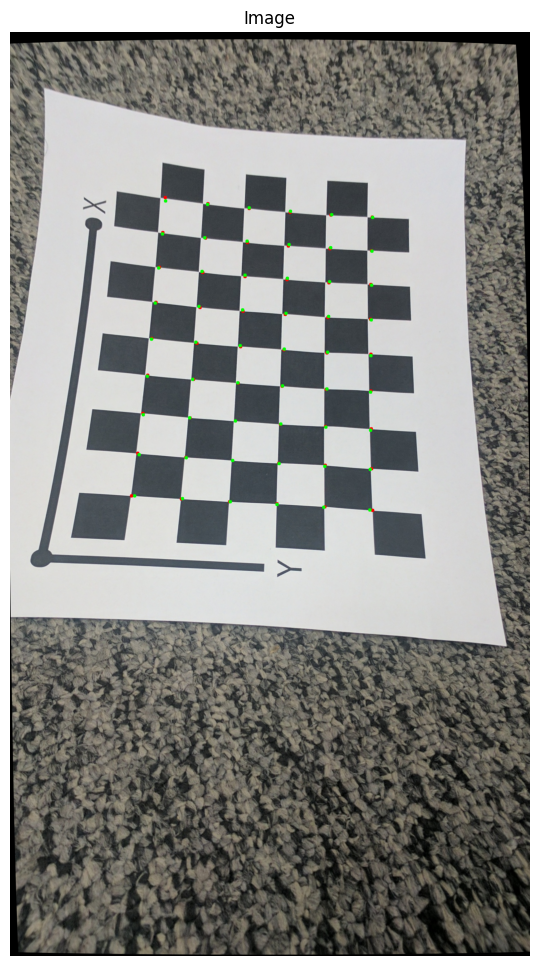

In [148]:
# show_two_banks(images_with_points, undistorted_images_with_points, 0, 5)
# show_two_banks(images_with_points, undistorted_images_with_points, 6, 11)
show_image(undistorted_images_with_points[5])


# ROUGH

In [103]:
# Create distorted  images

image_dir = r"F:\CV\RBE549\Nehal_hw1\Calibration_Imgs"
undistorted_img_dir =r"F:\CV\RBE549\Nehal_hw1\distored_calib_imgs"
os.makedirs(undistorted_img_dir, exist_ok=True)

all_files = os.listdir(image_dir)
image_names = [f for f in all_files if f.lower().endswith(".jpg")]
image_indices_temp = range(len(image_names))

images=[]
undistorted_images=[]
ks =np.array([-0.5, -0.2,  0, 0, 0])
for index in image_indices_temp:
    image = cv2.imread(os.path.join(image_dir, image_names[index]))
    undistorted_img_path = os.path.join(undistorted_img_dir, image_names[index])
    undistorted_img = cv2.undistort(image, K, ks)
    cv2.imwrite(undistorted_img_path, undistorted_img)
    images.append(image)
    undistorted_images.append(undistorted_img)



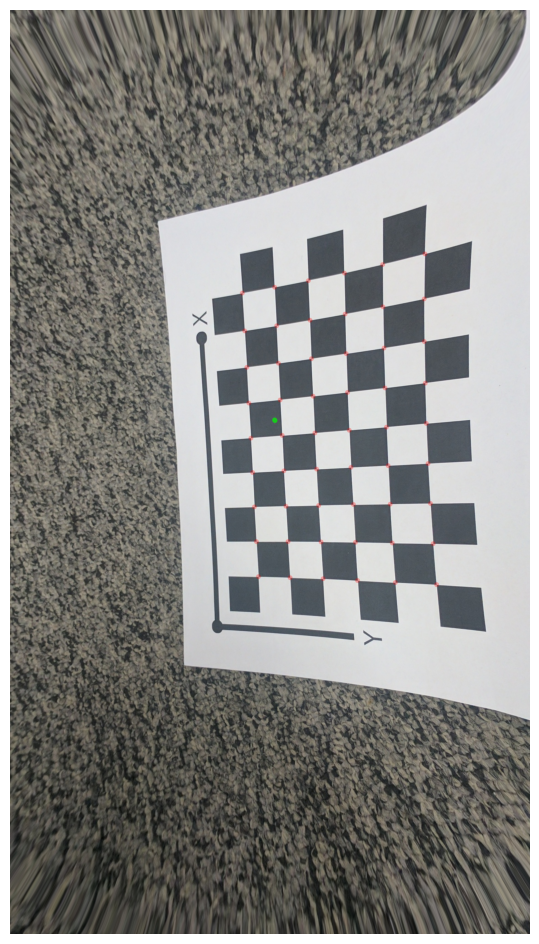

In [73]:
combined_image_img1 = cv2.imread(r"F:\CV\RBE549\Nehal_hw1\Results\reprojected_12.png")
combined_image_img2= cv2.imread(r"F:\CV\RBE549\Nehal_hw1\Results\original_corners_12.png")

alpha = 0.7
combined_image = combined_image_img1 * alpha + combined_image_img2 * (1 - alpha)
combined_image = np.clip(combined_image, 0, 255).astype(np.uint8)
show_image(combined_image, "")